In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [91]:
df_2mm_baseline = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_baseline_rep01_photon_boundaries.csv")
df_2mm_40_loc = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_40_Rn222_loc_rep01_photon_boundaries.csv")
df_2mm_50_diff = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_50diffRn222_rep01_photon_boundaries.csv")
df_2mm_10_diff = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_10diffRn222_rep01_photon_boundaries.csv")
df_2mm_90_diff = pd.read_csv("./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs/2mm_2mm_10k_90diffRn222_rep01_photon_boundaries.csv")

In [134]:
def leakage_region(df,  panel='physPhotonDetectorPosY', coord_range=(-950, 950), coord='z_mm'):
    selected_df = df[(df['volumeName']==panel) 
                 & (df['boundary']=='enter') 
                 & (df[coord].between(*coord_range, inclusive='both'))
                 ]['z_mm']
    return selected_df


In [61]:
df_2mm_baseline['z_mm'].describe()

count    36114.000000
mean         1.114737
std        199.735668
min       -950.000000
25%        -67.707400
50%          0.720592
75%         73.011900
max        950.000000
Name: z_mm, dtype: float64

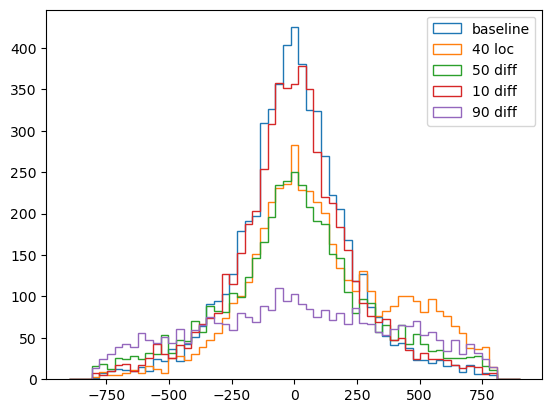

In [92]:
coord_range = (-900, 900)
bins = np.linspace(coord_range[0], coord_range[1], 60)
plt.figure()
plt.hist(leakage_region(df_2mm_baseline, coord_range=coord_range), histtype=u'step',bins = bins,  label='baseline')
plt.hist(leakage_region(df_2mm_40_loc, coord_range=coord_range), histtype=u'step',bins = bins,  label='40 loc')
plt.hist(leakage_region(df_2mm_50_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='50 diff')
plt.hist(leakage_region(df_2mm_10_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='10 diff')
plt.hist(leakage_region(df_2mm_90_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='90 diff')
plt.legend()
plt.show()


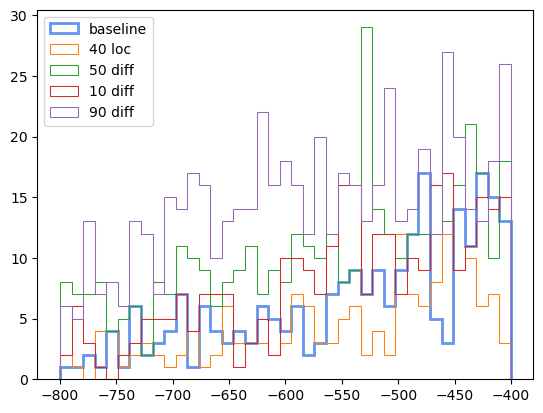

In [ ]:
coord_range = (-800, -400)
bins = np.linspace(coord_range[0], coord_range[1], 40)
plt.figure()
plt.hist(leakage_region(df_2mm_baseline, coord_range=coord_range), histtype=u'step',bins = bins,  label='baseline', linewidth=2, edgecolor='cornflowerblue')
plt.hist(leakage_region(df_2mm_40_loc, coord_range=coord_range), histtype=u'step',bins = bins,  label='40 loc' , linewidth=.75)
plt.hist(leakage_region(df_2mm_50_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='50 diff', linewidth=.75)
plt.hist(leakage_region(df_2mm_10_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='10 diff', linewidth=.75)
plt.hist(leakage_region(df_2mm_90_diff, coord_range=coord_range), histtype=u'step',bins = bins,  label='90 diff', linewidth=.75)
plt.legend()
plt.show()

In [108]:
cases = [10, 50, 90]
reps = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10"]

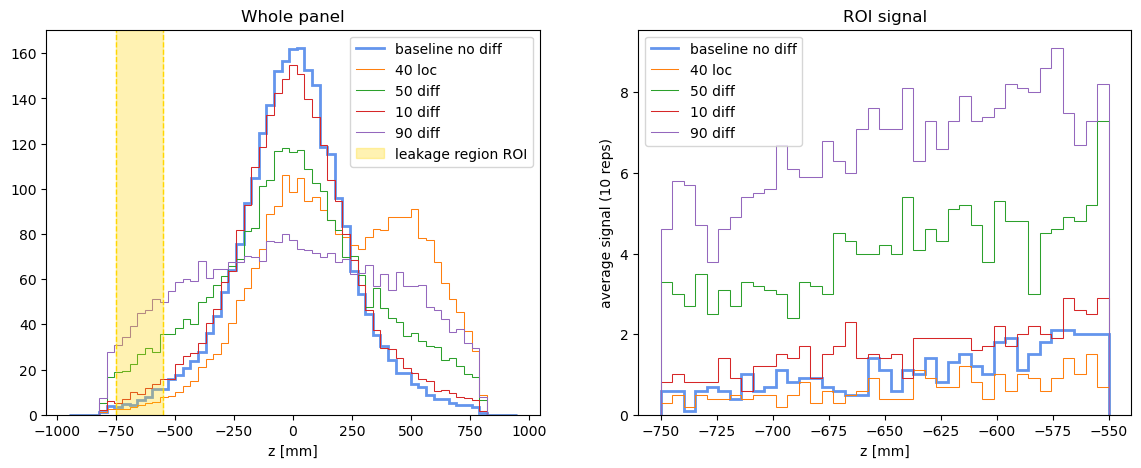

In [166]:
output_dir = "./rn222_repetition_runs/rn222_2mmfully_10reps_10k/outputs"
case_files = {
    "baseline no diff": "2mm_2mm_10k_baseline_rep{rep}_photon_boundaries.csv",
    "40 loc": "2mm_2mm_10k_40_Rn222_loc_rep{rep}_photon_boundaries.csv",
    "50 diff": "2mm_2mm_10k_50diffRn222_rep{rep}_photon_boundaries.csv",
    "10 diff": "2mm_2mm_10k_10diffRn222_rep{rep}_photon_boundaries.csv",
    "90 diff": "2mm_2mm_10k_90diffRn222_rep{rep}_photon_boundaries.csv",
}
case_colors = {
    "baseline no diff": "cornflowerblue",
    "40 loc": "tab:orange",
    "50 diff": "tab:green",
    "10 diff": "tab:red",
    "90 diff": "tab:purple",
}

coord_range = (-750, -550)
bins = np.linspace(coord_range[0], coord_range[1], 40)
panel = "physPhotonDetectorPosX"
fig, ax = plt.subplots(1,2, figsize=(14, 5))

bins_full = np.linspace(-950, 950, 60)


for label, filename_template in case_files.items():
    leakage_rep_counts = []
    full_rep_counts = []
    for rep in reps:
        path = os.path.join(output_dir, filename_template.format(rep=rep))
        df = pd.read_csv(path)
        leakage_signal = leakage_region(df, coord_range=coord_range, panel="physPhotonDetectorPosX")
        full_signal = leakage_region(df, panel="physPhotonDetectorPosX")
        leakage_counts, _ = np.histogram(leakage_signal, bins=bins)
        full_counts, _ = np.histogram(full_signal, bins=bins_full)
        leakage_rep_counts.append(leakage_counts)
        full_rep_counts.append(full_counts)
    mean_leakage_counts = np.mean(leakage_rep_counts, axis=0)
    mean_full_counts = np.mean(full_rep_counts, axis=0)
    
    linewidth = 2 if "baseline" in label else .75
    ax[1].stairs(mean_leakage_counts, bins, label=label, linewidth=linewidth, color=case_colors[label])
    ax[0].stairs(mean_full_counts, bins_full, label=label, linewidth=linewidth, color=case_colors[label])
ax[0].axvspan(coord_range[0], coord_range[1], color='gold', alpha=0.3, label='leakage region ROI')
ax[0].axvline(coord_range[0], c='gold', linestyle='--', linewidth=1)
ax[0].axvline(coord_range[1], c='gold', linestyle='--', linewidth=1)
ax[0].set_xlabel("z [mm]")
ax[0].legend()
ax[0].set_title("Whole panel")
ax[1].set_xlabel("z [mm]")
ax[1].set_title("ROI signal")
plt.ylabel("average signal (10 reps)")
plt.legend()
plt.show()